# 📚 Book Catalog Web Scraping & Analysis

## CodeAlpha Data Analytics Internship — Task 1

### Project Objective

The objective of this project is to collect book-related information from a publicly available website using Python web scraping techniques.

The project uses `Requests` and `BeautifulSoup` to extract book information and `Pandas` to organize and clean the collected data.

The scraped dataset is then analyzed using Python and visualized using Matplotlib.

## 1. Project Overview

In this project, data was collected from the Books to Scrape website.

The following information was collected:

- Book Title
- Price
- Rating
- Availability
- Stock information
- Book Category
- Book URL

A total of 1,000 book records were collected from 50 catalog pages.

In [2]:
!pip install requests beautifulsoup4 pandas

## 2. Libraries Used

| Library | Purpose |
|---|---|
| Requests | Sending HTTP requests to the website |
| BeautifulSoup | Parsing HTML and extracting information |
| Pandas | Data manipulation and analysis |
| Matplotlib | Data visualization |
| urllib.parse | Constructing complete URLs |

In [88]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from urllib.parse import urljoin


## 3. Import Required Libraries

In [96]:
import requests

https://books.toscrape.com/

## 4. Website Connection

The website is accessed using the Requests library.

A successful HTTP response with status code `200` confirms that the webpage was successfully retrieved.

In [14]:
url = "https://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)

200


## 5. HTML Parsing and Data Extraction

BeautifulSoup is used to parse the HTML structure of the webpage.

The book cards are identified using their HTML structure and relevant CSS classes.

In [15]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title.text)


    All products | Books to Scrape - Sandbox



In [16]:
books = soup.select("article.product_pod")

print(len(books))

20


In [17]:
book = books[0]

print(book.get_text(" ", strip=True))

A Light in the ... Â£51.77 In stock Add to basket


In [18]:
title = book.h3.a["title"]

print(title)

A Light in the Attic


In [19]:
price = book.select_one(".price_color").text.strip()

print(price)

Â£51.77


In [20]:
rating = book.select_one("p.star-rating")["class"][1]

print(rating)

Three


In [21]:
availability = book.select_one(".availability").get_text(" ", strip=True)

print(availability)

In stock


In [24]:
book_link = book.h3.a["href"]

book_url = urljoin(url, book_link)

print(book_url)

https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html


In [25]:
book_data = {
    "Title": title,
    "Price": price,
    "Rating": rating,
    "Availability": availability,
    "URL": book_url
}

print(book_data)

{'Title': 'A Light in the Attic', 'Price': 'Â£51.77', 'Rating': 'Three', 'Availability': 'In stock', 'URL': 'https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html'}


## 6. Web Scraping

A reusable function is created to extract the required information from each book.

The scraper collects:

- Title
- Price
- Rating
- Availability
- URL
- Category

In [26]:
def scrape_book(book, base_url):
    
    title = book.h3.a["title"]
    
    price = book.select_one(".price_color").text.strip()
    
    rating = book.select_one("p.star-rating")["class"][1]
    
    availability = book.select_one(".availability").get_text(" ", strip=True)
    
    book_link = book.h3.a["href"]
    book_url = urljoin(base_url, book_link)
    
    return {
        "Title": title,
        "Price": price,
        "Rating": rating,
        "Availability": availability,
        "URL": book_url
    }

In [28]:
scrape_book(books[6], url)

{'Title': 'The Dirty Little Secrets of Getting Your Dream Job',
 'Price': 'Â£33.34',
 'Rating': 'Four',
 'Availability': 'In stock',
 'URL': 'https://books.toscrape.com/catalogue/the-dirty-little-secrets-of-getting-your-dream-job_994/index.html'}

In [29]:
data = []

for book in books:
    data.append(scrape_book(book, url))

print(len(data))

20


## 7. Data Cleaning

The scraped data is cleaned and converted into suitable data types.

The following transformations are performed:

- Price is converted from text to numerical values.
- Rating values such as "One" and "Five" are converted into numbers.
- Stock quantities are extracted from availability information.
- Missing stock quantities are retained as missing values when the website does not provide a specific quantity.

In [30]:
df = pd.DataFrame(data)

df

,Title,Price,Rating,Availability,URL
0,A Light in the Attic,Â£51.77,Three,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,One,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,One,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,Four,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,https://books.toscrape.com/catalogue/sapiens-a...
5,The Requiem Red,Â£22.65,One,In stock,https://books.toscrape.com/catalogue/the-requi...
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,Four,In stock,https://books.toscrape.com/catalogue/the-dirty...
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,Three,In stock,https://books.toscrape.com/catalogue/the-comin...
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,Four,In stock,https://books.toscrape.com/catalogue/the-boys-...
9,The Black Maria,Â£52.15,One,In stock,https://books.toscrape.com/catalogue/the-black...


In [31]:
df.head()

,Title,Price,Rating,Availability,URL
0,A Light in the Attic,Â£51.77,Three,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,One,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,One,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,Four,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,https://books.toscrape.com/catalogue/sapiens-a...


In [33]:
df.shape

(20, 5)

In [34]:
df.columns


Index(['Title', 'Price', 'Rating', 'Availability', 'URL'], dtype='str')

In [35]:
all_books = []

for page in range(1, 51):
    
    page_url = f"https://books.toscrape.com/catalogue/page-{page}.html"
    
    response = requests.get(page_url)
    
    soup = BeautifulSoup(response.text, "html.parser")
    
    books = soup.select("article.product_pod")
    
    for book in books:
        book_data = scrape_book(book, page_url)
        all_books.append(book_data)
    
    print(f"Page {page}: {len(books)} books scraped")

Page 1: 20 books scraped
Page 2: 20 books scraped
Page 3: 20 books scraped
Page 4: 20 books scraped
Page 5: 20 books scraped
Page 6: 20 books scraped
Page 7: 20 books scraped
Page 8: 20 books scraped
Page 9: 20 books scraped
Page 10: 20 books scraped
Page 11: 20 books scraped
Page 12: 20 books scraped
Page 13: 20 books scraped
Page 14: 20 books scraped
Page 15: 20 books scraped
Page 16: 20 books scraped
Page 17: 20 books scraped
Page 18: 20 books scraped
Page 19: 20 books scraped
Page 20: 20 books scraped
Page 21: 20 books scraped
Page 22: 20 books scraped
Page 23: 20 books scraped
Page 24: 20 books scraped
Page 25: 20 books scraped
Page 26: 20 books scraped
Page 27: 20 books scraped
Page 28: 20 books scraped
Page 29: 20 books scraped
Page 30: 20 books scraped
Page 31: 20 books scraped
Page 32: 20 books scraped
Page 33: 20 books scraped
Page 34: 20 books scraped
Page 35: 20 books scraped
Page 36: 20 books scraped
Page 37: 20 books scraped
Page 38: 20 books scraped
Page 39: 20 books scr

In [36]:
print("Total books scraped:", len(all_books))

Total books scraped: 1000


In [37]:
df.head()

,Title,Price,Rating,Availability,URL
0,A Light in the Attic,Â£51.77,Three,In stock,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,One,In stock,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,One,In stock,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,Four,In stock,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,https://books.toscrape.com/catalogue/sapiens-a...


## 8. Data Quality Checks

The dataset is checked for:

- Missing values
- Duplicate records
- Data types
- Dataset dimensions

These checks help ensure that the scraped data is suitable for further analysis.

In [38]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Title         20 non-null     str  
 1   Price         20 non-null     str  
 2   Rating        20 non-null     str  
 3   Availability  20 non-null     str  
 4   URL           20 non-null     str  
dtypes: str(5)
memory usage: 932.0 bytes


In [39]:
df.isnull().sum()

Title           0
Price           0
Rating          0
Availability    0
URL             0
dtype: int64

In [41]:
df.duplicated().sum()

np.int64(0)

print(repr(df["Price"].iloc[0]))

In [44]:
df["Price"] = df["Price"].str.extract(r"(\d+(?:\.\d+)?)")[0].astype(float)

In [45]:
df["Price"].head()

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: float64

In [46]:
all_books = []

for page in range(1, 51):
    
    page_url = f"https://books.toscrape.com/catalogue/page-{page}.html"
    
    response = requests.get(page_url)
    
    soup = BeautifulSoup(response.text, "html.parser")
    
    books = soup.select("article.product_pod")
    
    for book in books:
        all_books.append(scrape_book(book, page_url))
    
    print(f"Page {page}: {len(books)} books scraped")

Page 1: 20 books scraped
Page 2: 20 books scraped
Page 3: 20 books scraped
Page 4: 20 books scraped
Page 5: 20 books scraped
Page 6: 20 books scraped
Page 7: 20 books scraped
Page 8: 20 books scraped
Page 9: 20 books scraped
Page 10: 20 books scraped
Page 11: 20 books scraped
Page 12: 20 books scraped
Page 13: 20 books scraped
Page 14: 20 books scraped
Page 15: 20 books scraped
Page 16: 20 books scraped
Page 17: 20 books scraped
Page 18: 20 books scraped
Page 19: 20 books scraped
Page 20: 20 books scraped
Page 21: 20 books scraped
Page 22: 20 books scraped
Page 23: 20 books scraped
Page 24: 20 books scraped
Page 25: 20 books scraped
Page 26: 20 books scraped
Page 27: 20 books scraped
Page 28: 20 books scraped
Page 29: 20 books scraped
Page 30: 20 books scraped
Page 31: 20 books scraped
Page 32: 20 books scraped
Page 33: 20 books scraped
Page 34: 20 books scraped
Page 35: 20 books scraped
Page 36: 20 books scraped
Page 37: 20 books scraped
Page 38: 20 books scraped
Page 39: 20 books scr

In [47]:
print("Total books:", len(all_books))

Total books: 1000


In [48]:
df = pd.DataFrame(all_books)

print(df.shape)

(1000, 5)


In [49]:
print(df.shape)

(1000, 5)


In [50]:
df.isnull().sum()

Title           0
Price           0
Rating          0
Availability    0
URL             0
dtype: int64

In [51]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [52]:
df["Price"] = df["Price"].str.extract(r"(\d+(?:\.\d+)?)")[0].astype(float)

In [53]:
df[["Title", "Price"]].head()

,Title,Price
0,A Light in the Attic,51.77
1,Tipping the Velvet,53.74
2,Soumission,50.10
3,Sharp Objects,47.82
4,Sapiens: A Brief History of Humankind,54.23


In [54]:
print(df["Price"].dtype)

float64


In [55]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

In [56]:
df["Rating"].value_counts().sort_index()

Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64

In [58]:
df[df["Availability"].str.extract(r"(\d+)")[0].isna()]["Availability"].unique()

<StringArray>
['In stock']
Length: 1, dtype: str

In [59]:
stock_values = df["Availability"].str.extract(r"(\d+)")[0]

df["Stock"] = pd.to_numeric(stock_values, errors="coerce")

In [60]:
df[["Availability", "Stock"]].head(10)

,Availability,Stock
0,In stock,NaN
1,In stock,NaN
2,In stock,NaN
3,In stock,NaN
4,In stock,NaN
5,In stock,NaN
6,In stock,NaN
7,In stock,NaN
8,In stock,NaN
9,In stock,NaN


In [61]:
df["Stock"] = df["Stock"].fillna(0)

In [62]:
df[["Availability", "Stock"]].head(10)

,Availability,Stock
0,In stock,0.0
1,In stock,0.0
2,In stock,0.0
3,In stock,0.0
4,In stock,0.0
5,In stock,0.0
6,In stock,0.0
7,In stock,0.0
8,In stock,0.0
9,In stock,0.0


In [63]:
df["Stock"] = stock_values

In [64]:
print(df.shape)

(1000, 6)


In [65]:
def get_category(book_url):
    try:
        response = requests.get(book_url, timeout=10)
        soup = BeautifulSoup(response.text, "html.parser")
        
        breadcrumb = soup.select("ul.breadcrumb li")
        
        if len(breadcrumb) >= 3:
            category = breadcrumb[2].get_text(strip=True)
        else:
            category = "Unknown"
            
        return category
    
    except Exception:
        return "Unknown"

In [68]:
test_url = df["URL"].iloc[3]

print(get_category(test_url))

Mystery


In [69]:
categories = []

for i, book_url in enumerate(df["URL"], start=1):
    category = get_category(book_url)
    categories.append(category)
    
    if i % 50 == 0:
        print(f"{i} books processed")

50 books processed
100 books processed
150 books processed
200 books processed
250 books processed
300 books processed
350 books processed
400 books processed
450 books processed
500 books processed
550 books processed
600 books processed
650 books processed
700 books processed
750 books processed
800 books processed
850 books processed
900 books processed
950 books processed
1000 books processed


In [70]:
df["Category"] = categories

In [71]:
df.head()

,Title,Price,Rating,Availability,URL,Stock,Category
0,A Light in the Attic,51.77,3,In stock,https://books.toscrape.com/catalogue/a-light-i...,NaN,Poetry
1,Tipping the Velvet,53.74,1,In stock,https://books.toscrape.com/catalogue/tipping-t...,NaN,Historical Fiction
2,Soumission,50.10,1,In stock,https://books.toscrape.com/catalogue/soumissio...,NaN,Fiction
3,Sharp Objects,47.82,4,In stock,https://books.toscrape.com/catalogue/sharp-obj...,NaN,Mystery
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,https://books.toscrape.com/catalogue/sapiens-a...,NaN,History


In [72]:
df["Category"].value_counts().head(10)

Category
Default           152
Nonfiction        110
Sequential Art     75
Add a comment      67
Fiction            65
Young Adult        54
Fantasy            48
Romance            35
Mystery            32
Food and Drink     30
Name: count, dtype: int64

In [73]:
df.to_csv("books_data.csv", index=False)

print("Final scraped dataset saved successfully!")

Final scraped dataset saved successfully!


In [74]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 7


In [75]:
df.isnull().sum()

Title              0
Price              0
Rating             0
Availability       0
URL                0
Stock           1000
Category           0
dtype: int64

In [76]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [77]:
df.dtypes

Title               str
Price           float64
Rating            int64
Availability        str
URL                 str
Stock               str
Category            str
dtype: object

In [78]:
print("Average Price:", round(df["Price"].mean(), 2))
print("Minimum Price:", df["Price"].min())
print("Maximum Price:", df["Price"].max())

Average Price: 35.07
Minimum Price: 10.0
Maximum Price: 59.99


## 9. Exploratory Data Analysis

Basic statistical analysis is performed to understand the scraped dataset.

The analysis focuses on:

- Book price distribution
- Rating distribution
- Category frequency
- Relationship between ratings and average price

In [79]:
print("Most common rating:")
print(df["Rating"].value_counts().sort_index())

Most common rating:
Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64


In [80]:
df["Category"].value_counts().head(10)

Category
Default           152
Nonfiction        110
Sequential Art     75
Add a comment      67
Fiction            65
Young Adult        54
Fantasy            48
Romance            35
Mystery            32
Food and Drink     30
Name: count, dtype: int64

In [81]:
df.groupby("Rating")["Price"].mean().round(2)

Rating
1    34.56
2    34.81
3    34.69
4    36.09
5    35.37
Name: Price, dtype: float64

In [86]:
!pip install matplotlib

## 10. Data Visualization

Matplotlib is used to visualize patterns and distributions within the scraped dataset.

In [89]:
import matplotlib.pyplot as plt

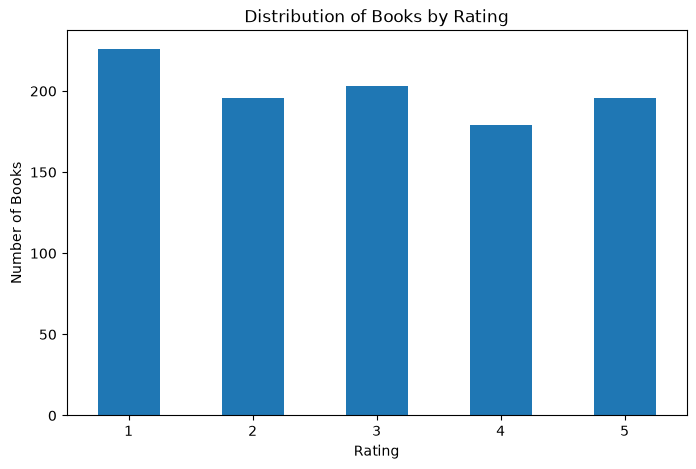

In [90]:
rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
rating_counts.plot(kind="bar")

plt.title("Distribution of Books by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)

plt.show()

In [92]:
category_counts = df["Category"].value_counts().head(10)

print(category_counts)

Category
Default           152
Nonfiction        110
Sequential Art     75
Add a comment      67
Fiction            65
Young Adult        54
Fantasy            48
Romance            35
Mystery            32
Food and Drink     30
Name: count, dtype: int64


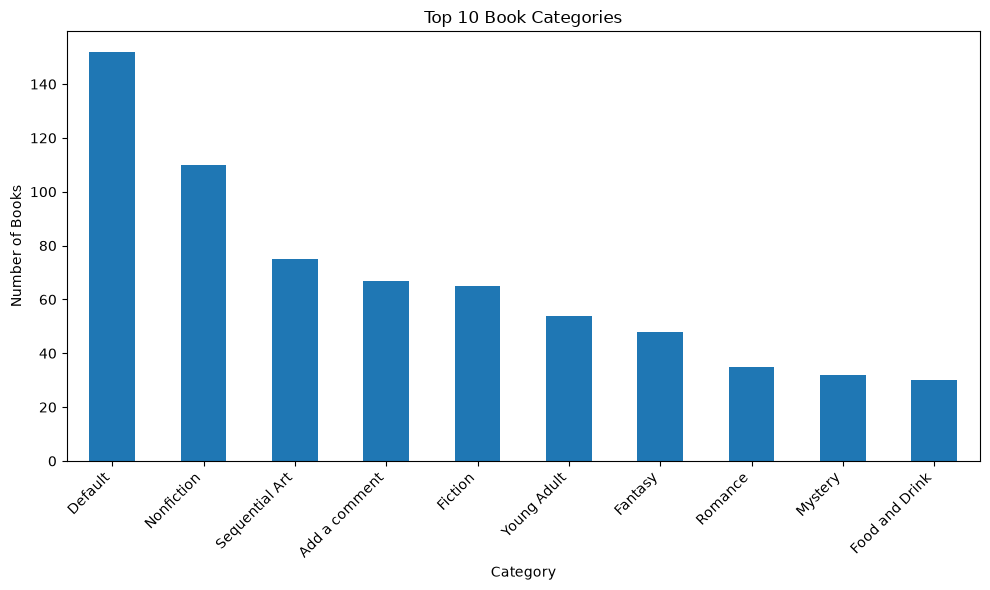

In [93]:
plt.figure(figsize=(10, 6))

category_counts.plot(kind="bar")

plt.title("Top 10 Book Categories")
plt.xlabel("Category")
plt.ylabel("Number of Books")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

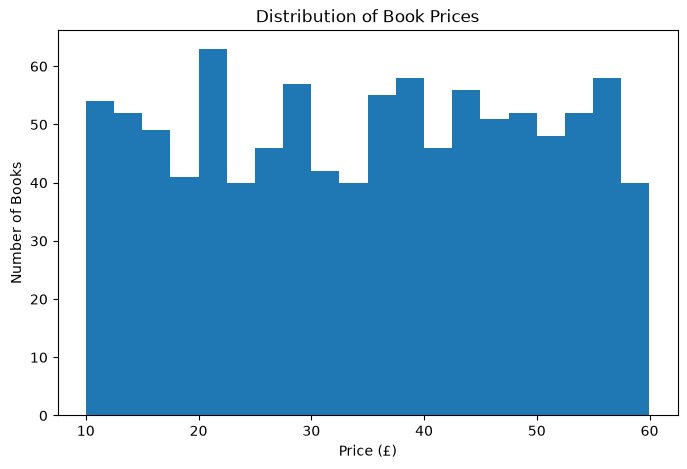

In [94]:
plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=20)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.show()

In [102]:
print("Average Price:", round(df["Price"].mean(), 2))
print("Minimum Price:", df["Price"].min())
print("Maximum Price:", df["Price"].max())
print("Most common category:", df["Category"].value_counts().idxmax())
print("Most common rating:", df["Rating"].value_counts().idxmax())

Average Price: 35.07
Minimum Price: 10.0
Maximum Price: 59.99
Most common category: Default
Most common rating: 1


In [103]:
test_url = df["URL"].iloc[0]

response = requests.get(test_url)
soup = BeautifulSoup(response.text, "html.parser")

print(soup.select_one("ul.breadcrumb").get_text(" > ", strip=True))
print(df["Category"].value_counts().head(15))

Home > Books > Poetry > A Light in the Attic
Category
Default               152
Nonfiction            110
Sequential Art         75
Add a comment          67
Fiction                65
Young Adult            54
Fantasy                48
Romance                35
Mystery                32
Food and Drink         30
Childrens              29
Historical Fiction     26
Poetry                 19
Classics               19
History                18
Name: count, dtype: int64


## 11. Key Findings

Based on the analysis of the scraped dataset, the following insights were observed:

1. A total of **1,000 book records** were collected from the Books to Scrape website.

2. The **average book price is £35.07**, while the minimum price is **£10.00** and the maximum price is **£59.99**.

3. The most frequently occurring book rating is **1 star**, with **226 books**, representing approximately **22.6%** of the dataset.

4. The most frequently represented category is **Default**, with **152 books**, followed by **Nonfiction (110 books)** and **Sequential Art (75 books)**.

5. The dataset contains books across **five rating levels**, from 1 star to 5 stars.

6. Some availability records only contain **"In stock"** without a specific quantity. Therefore, the exact stock quantity could not be determined for those records.

7. The visualizations help identify patterns in book ratings, categories, and prices within the scraped dataset.

## 12. Conclusion

This project demonstrates the complete basic web scraping workflow using Python. Data was collected from a publicly available website using Requests and BeautifulSoup, structured and cleaned using Pandas, and analyzed and visualized using Python.

The project provided practical experience in HTML parsing, web navigation, data extraction, data cleaning, exploratory analysis, and visualization.

In [104]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current folder:
C:\Users\vivek

Files in this folder:
['.android', '.copilot', '.gemini', '.ipynb_checkpoints', '.ipython', '.jupyter', '.ssh', '.vscode', '.vscode-shared', 'AppData', 'Application Data', 'books_data.csv', 'CodeAlpha_Web_Scraping.ipynb', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{172f92a1-b69a-11f1-a0bb-1cbfcec28d0a}.TM.blf', 'NTUSER.DAT{172f92a1-b69a-11f1-a0bb-1cbfcec28d0a}.TM.blf.cnpf', 'NTUSER.DAT{172f92a1-b69a-11f1-a0bb-1cbfcec28d0a}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{172f92a1-b69a-11f1-a0bb-1cbfcec28d0a}.TMContainer00000000000000000001.regtrans-ms.cnpf', 'NTUSER.DAT{172f92a1-b69a-11f1-a0bb-1cbfcec28d0a}.TMContainer00000000000000000002.regtrans-ms', 'NTUSER.DAT{172f92a1-b69a-11f1-a0bb-1cbfcec28d0a}.TMContainer00000000000000000002.regtrans-ms.cnpf', 'ntuser.ini', 'O